# Waveform evaluation time per lens model
For each model, draw `N` samples from the glow_waveforms.glow_bilby default priors (BBH + lens priors of that model) and time
`WaveformGenerator.frequency_domain_strain` (4 s, 2048 Hz, IMRPhenomXPNR, $f_{\rm min}=20$ Hz). This is the cost
per likelihood call, excluding the likelihood itself. One warm-up call is made on a separate sample.
Failures (F(w) could not be computed, so the likelihood is $-\infty$) are counted separately.
The same is available from the command line: `python timing_waveforms.py --n-samples 100`.

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import bilby
from timing_waveforms import run, plot

bilby.core.utils.logger.setLevel('WARNING')
N_SAMPLES = 100
APPROXIMANT = 'IMRPhenomXPHM'

In [6]:
rows, all_times = run(n_samples=N_SAMPLES, approximant=APPROXIMANT)

UL                   6.4 +-     2.2 ms  [3.6, 11.6]  fail 0%
PL                   9.0 +-     3.2 ms  [4.5, 17.9]  fail 0%


SIS                  9.6 +-     7.4 ms  [5.5, 78.2]  fail 0%
gSIS                 9.9 +-     2.8 ms  [5.3, 17.3]  fail 0%
NFW                  9.2 +-     2.6 ms  [5.3, 16.6]  fail 0%
PLshear             15.5 +-     3.5 ms  [9.8, 28.0]  fail 0%


PLshear_kpeqg1      20.0 +-    13.7 ms  [9.9, 119.2]  fail 0%


gSISshear           28.6 +-    26.0 ms  [12.1, 190.4]  fail 0%


In [7]:
print('{:15s} {:>10s} {:>9s} {:>9s} {:>9s} {:>9s} {:>7s}'.format(
    'model', 'mean[ms]', 'std', 'median', 'min', 'max', 'fail'))
for model, r in rows.items():
    print('{:15s} {:10.1f} {:9.1f} {:9.1f} {:9.1f} {:9.1f} {:7.0%}'.format(
        model, r['mean_ms'], r['std_ms'], r['median_ms'], r['min_ms'], r['max_ms'], r['fail_rate']))
ul = rows['UL']['mean_ms']
print('\nlensing overhead w.r.t. UL (mean): ' +
      ', '.join('{} x{:.1f}'.format(m, r['mean_ms'] / ul) for m, r in rows.items() if m != 'UL'))

model             mean[ms]       std    median       min       max    fail
UL                     6.4       2.2       5.5       3.6      11.6      0%
PL                     9.0       3.2       7.7       4.5      17.9      0%
SIS                    9.6       7.4       8.3       5.5      78.2      0%
gSIS                   9.9       2.8       9.4       5.3      17.3      0%
NFW                    9.2       2.6       8.6       5.3      16.6      0%
PLshear               15.5       3.5      14.8       9.8      28.0      0%
PLshear_kpeqg1        20.0      13.7      15.9       9.9     119.2      0%
gSISshear             28.6      26.0      22.0      12.1     190.4      0%

lensing overhead w.r.t. UL (mean): PL x1.4, SIS x1.5, gSIS x1.5, NFW x1.4, PLshear x2.4, PLshear_kpeqg1 x3.1, gSISshear x4.4


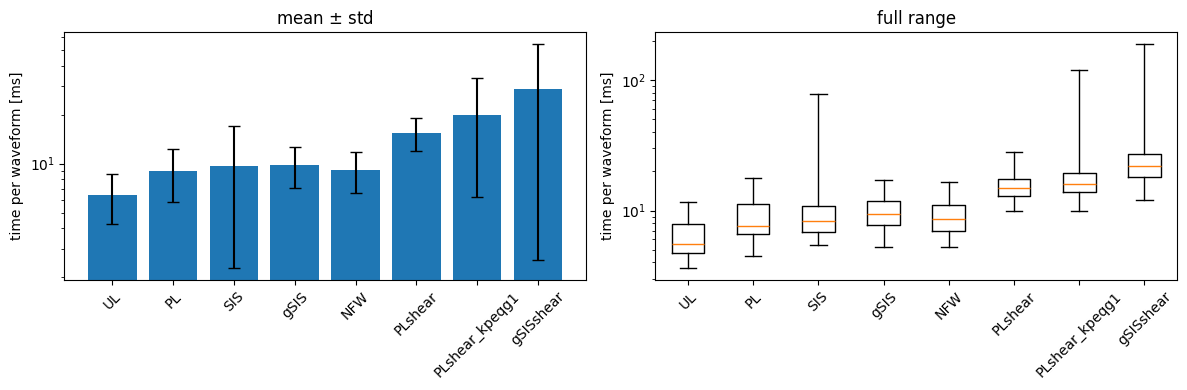

In [8]:
fig = plot(rows, all_times)
plt.show()